# El Trilema de la Gamarra
## Simulación Multiagente de Informalidad y Evasión Tributaria en el Perú

Modelo MAS con framework **Mesa 3.5** que simula la dinámica de formalidad/evasión/informalidad
en el comercio minorista peruano. Tres tipos de agentes interactúan en un grid:

- **Comerciante** — decide estrategia vía Logit Multinomial (formal / evasor / informal)
- **Consumidor** — móvil, compra por utilidad precio + moral tributaria
- **Sunat** — fiscaliza con gradualidad y discrecionalidad

**Datos reales (2025-2026):** UIT S/ 5,500 | RMV S/ 1,130 | IGV 18% | Informalidad 70.2% (INEI EPEN)

**Requisitos:** `pip install mesa pandas matplotlib`

## Marco Teórico

### Contexto tributario peruano

| Régimen | Tope ingresos | Tasa |
|---|---|---|
| NRUS | 8 UIT/año (S/ 42,800) | Cuota fija S/ 20–50/mes |
| RER | 525 UIT/año | 1.5% sobre ingresos netos |
| MYPE Tributario (RMT) | 1,700 UIT/año | 1%–1.5% |
| Régimen General | Sin tope | 29.5% |

### El trilema fundamental

El regulador **no puede maximizar simultáneamente**:
1. Recaudación (formalidad amplia)
2. Estándares formales (cumplimiento pleno)
3. Estabilidad del empleo microempresarial (no destruir capital)

### Causas estructurales modeladas

- **Altos costos de formalidad** (IGV 18%, aportes laborales ~30%, contabilidad)
- **Enanismo empresarial** (98% son microempresas, sin escala para absorber costos fijos)
- **Baja fiscalización** (SUNAT no llega a millones de microcomerciantes)
- **Baja moral tributaria** (consumidores priorizan precio, no exigen comprobante)
- **Pobreza** (bien informal ~15% más barato = subsidio de mercado)

### Políticas activables

1. **Beneficio por antigüedad formal** — descuento incremental en costo fijo por ciclo formal consecutivo
2. **Sorteo de comprobantes** — consumidor que compra formal tiene chance de premio
3. **Multa progresiva por reincidencia** — 1ra=acta, 2da=multa base, 3ra+=multa × factor

In [1]:
"""Parámetros económicos, impositivos y laborales. Bienio 2025-2026."""

# Macroeconómicos
UIT_2025 = 5350.0
UIT_2026 = 5500.0
RMV_2025 = 1130.0
UIT_VIGENTE = UIT_2026
RMV_VIGENTE = RMV_2025

# Tributarios
TASA_IGV = 0.18  # 18% (16% IGV + 2% IPM)
MULTA_NO_EMISION = 0.50 * UIT_VIGENTE  # S/ 2750
DESCUENTO_GRADUALIDAD = 0.90
MULTA_EVASION_PCT = 0.30  # 30% de ingresos ocultos

# Costos laborales REMYPE (1 trabajador)
COSTO_SIS_EMPLEADOR = 15.00
VACACIONES_PROVISION = (RMV_VIGENTE / 30.0) * 15.0 / 12.0  # ~47.08
COSTO_LABORAL_MENSUAL = RMV_VIGENTE + COSTO_SIS_EMPLEADOR + VACACIONES_PROVISION  # ~1192

# Costo fijo de formalidad (contabilidad + trámites + aportes)
COSTO_FIJO_FORMALIDAD = 400.00

# Comerciante
PRECIO_BASE = 30.0
COSTO_UNITARIO = 12.0
CAPITAL_INICIAL = 4000.0
ALPHA_EVASION = 0.60  # fracción de ventas no reportadas
DISTRIBUCION_INICIAL = ["formal", "evasor", "informal", "informal"]  # 25/25/50

# Consumidor
PRESUPUESTO_MEDIA = 200.0
PRESUPUESTO_DESV = 40.0
MORAL_MIN = 0.05
MORAL_MAX = 0.35

# Modelo
N_COMERCIANTES = 40
N_CONSUMIDORES = 800
AGRESIVIDAD_SUNAT = 0.55
TASA_DISCRECIONALIDAD = 0.30
SENSIBILIDAD_MERCADO = 3.0  # beta del Logit
PESO_PRECIO = 0.80
PESO_MORAL = 0.20
WIDTH = 15
HEIGHT = 15
SEED = 42

print("Parámetros cargados — UIT S/","{:.0f}".format(UIT_VIGENTE), "| RMV S/","{:.0f}".format(RMV_VIGENTE), "| IGV", TASA_IGV)

Parámetros cargados — UIT S/ 5500 | RMV S/ 1130 | IGV 0.18


In [2]:
import math
import mesa


class Comerciante(mesa.Agent):
    """3 estrategias: formal / evasor / informal. Decisión por Logit Multinomial."""

    def __init__(self, model, estrategia="informal", capital=CAPITAL_INICIAL):
        super().__init__(model)
        self.estrategia = estrategia
        self.capital = capital
        self.ventas_ciclo = 0
        self.ingresos_declarados = 0.0
        self.ingresos_ocultos = 0.0
        self.multas_pagadas = 0.0
        self.ciclos_formal_consecutivos = 0
        self.infracciones = 0

    def _costo_fijo_efectivo(self):
        costo = self.model.costo_fijo_formalidad
        if self.model.beneficio_antiguedad and self.estrategia == "formal":
            descuento = min(0.50, self.model.tasa_descuento_antiguedad * self.ciclos_formal_consecutivos)
            costo *= (1.0 - descuento)
        return costo

    def calcular_precio(self):
        igv = self.model.tasa_igv
        alpha = self.model.alpha_evasion
        if self.estrategia == "formal":
            return PRECIO_BASE * (1.0 + igv)
        elif self.estrategia == "evasor":
            return (PRECIO_BASE * (1.0 - alpha)) * (1.0 + igv) + PRECIO_BASE * alpha
        else:
            return PRECIO_BASE

    def estimar_utilidad_futura(self, est):
        volumen = max(1, self.ventas_ciclo)
        ingresos = PRECIO_BASE * volumen
        costos = COSTO_UNITARIO * volumen
        p_ins = self.model.prob_inspeccion_percibida
        igv = self.model.tasa_igv
        alpha = self.model.alpha_evasion
        cf = self.model.costo_fijo_formalidad
        disc = self.model.tasa_discrecionalidad

        if est == "formal":
            util = (ingresos / (1.0 + igv)) - costos
            renta = max(0.0, util * 0.10)
            cf_est = cf
            if self.model.beneficio_antiguedad:
                d = min(0.50, self.model.tasa_descuento_antiguedad * (self.ciclos_formal_consecutivos + 1))
                cf_est = cf * (1.0 - d)
            return (util - renta) - cf_est
        elif est == "informal":
            multa = self.model.multa_no_emision + 0.50 * ingresos
            penalidad = p_ins * multa * (1.0 - disc)
            return ingresos - costos - penalidad
        elif est == "evasor":
            ing_dec = (ingresos * (1.0 - alpha)) / (1.0 + igv)
            ing_ocu = ingresos * alpha
            util_dec = ing_dec - (costos * (1.0 - alpha))
            renta = max(0.0, util_dec * 0.10)
            multa_ev = p_ins * (self.model.multa_evasion_pct * ingresos * alpha) * (1.0 - disc)
            return (util_dec - renta - cf * 0.40) + (ing_ocu - costos * alpha - multa_ev)
        return 0.0

    def ajustar_cumplimiento(self):
        beta = self.model.sensibilidad_mercado
        utils = {est: self.estimar_utilidad_futura(est) for est in ("formal", "evasor", "informal")}
        expos = {}
        for est, u in utils.items():
            try:
                expos[est] = math.exp(min(500.0, beta * u / 10000.0))
            except OverflowError:
                expos[est] = math.exp(500.0)
        total = sum(expos.values())
        probs = {est: e / total for est, e in expos.items()}
        r = self.random.random()
        acum = 0.0
        for est, p in probs.items():
            acum += p
            if r <= acum:
                if est != self.estrategia and self.estrategia == "formal":
                    self.ciclos_formal_consecutivos = 0
                self.estrategia = est
                return

    def step(self):
        self.ajustar_cumplimiento()
        self.ventas_ciclo = 0
        self.ingresos_declarados = 0.0
        self.ingresos_ocultos = 0.0
        if self.estrategia == "formal":
            self.ciclos_formal_consecutivos += 1
            self.capital -= self._costo_fijo_efectivo()
        elif self.estrategia == "evasor":
            self.capital -= self.model.costo_fijo_formalidad * 0.40


In [3]:
class Consumidor(mesa.Agent):
    """Móvil, presupuesto gaussiano, moral tributaria baja."""

    def __init__(self, model):
        super().__init__(model)
        self.moral_tributaria = self.random.uniform(MORAL_MIN, MORAL_MAX)
        self.presupuesto = self.random.gauss(PRESUPUESTO_MEDIA, PRESUPUESTO_DESV)

    def _valor_esperado_sorteo(self):
        if self.model.sorteo_comprobantes:
            return self.model.prob_sorteo * self.model.premio_sorteo
        return 0.0

    def realizar_compra(self):
        while self.presupuesto > PRECIO_BASE:
            vecinos = self.model.grid.get_neighbors(self.pos, moore=True, include_center=False)
            comerciantes = [v for v in vecinos if isinstance(v, Comerciante)]
            if not comerciantes:
                self.mover()
                vecinos = self.model.grid.get_neighbors(self.pos, moore=True, include_center=False)
                comerciantes = [v for v in vecinos if isinstance(v, Comerciante)]
                if not comerciantes:
                    return
            mejor = None
            max_util = -float("inf")
            sorteo_ev = self._valor_esperado_sorteo()
            for c in comerciantes:
                precio = c.calcular_precio()
                if precio > self.presupuesto:
                    continue
                comprobante = 1.0 if c.estrategia in ("formal", "evasor") else 0.0
                bonus = sorteo_ev if c.estrategia == "formal" else 0.0
                util = (-(self.model.peso_precio * precio)
                        + (self.model.peso_moral * self.moral_tributaria * comprobante)
                        + bonus)
                if util > max_util:
                    max_util = util
                    mejor = c
            if mejor is not None:
                self.ejecutar_transaccion(mejor)
            else:
                self.mover()

    def ejecutar_transaccion(self, comerciante):
        precio = comerciante.calcular_precio()
        self.presupuesto -= precio
        comerciante.ventas_ciclo += 1
        comerciante.capital += precio
        igv = self.model.tasa_igv
        alpha = self.model.alpha_evasion
        if comerciante.estrategia == "formal":
            comerciante.ingresos_declarados += precio
            self.model.recaudacion_ciclo += precio * (igv / (1.0 + igv))
            if self.model.sorteo_comprobantes and self.random.random() < self.model.prob_sorteo:
                self.presupuesto += self.model.premio_sorteo
        elif comerciante.estrategia == "evasor":
            if self.random.random() > alpha:
                comerciante.ingresos_declarados += precio
                self.model.recaudacion_ciclo += precio * (igv / (1.0 + igv))
            else:
                comerciante.ingresos_ocultos += precio
        else:
            comerciante.ingresos_ocultos += precio

    def mover(self):
        pasos = self.model.grid.get_neighborhood(self.pos, moore=True, include_center=False)
        self.model.grid.move_agent(self, self.random.choice(pasos))

    def step(self):
        self.presupuesto = self.random.gauss(PRESUPUESTO_MEDIA, PRESUPUESTO_DESV)
        self.realizar_compra()


In [4]:
class Sunat(mesa.Agent):
    """Fiscalización con gradualidad y discrecionalidad."""

    def __init__(self, model):
        super().__init__(model)
        self.tasa_cobertura = model.agresividad_sunat
        self.multas_emitidas = 0
        self.cierres_ejecutados = 0
        self.actas_preventivas = 0

    def _factor_reincidencia(self, c):
        if not self.model.multa_progresiva:
            return 1.0
        if c.infracciones == 0:
            return 0.0
        elif c.infracciones == 1:
            return 1.0
        else:
            return self.model.factor_reincidencia ** (c.infracciones - 1)

    def fiscalizar_mercado(self):
        comerciantes = list(self.model.agents.select(agent_type=Comerciante))
        if not comerciantes:
            return
        n = int(len(comerciantes) * self.tasa_cobertura)
        muestra = self.random.sample(comerciantes, min(n, len(comerciantes)))
        for c in muestra:
            if c.estrategia == "informal":
                factor = self._factor_reincidencia(c)
                if factor == 0.0 or self.random.random() < self.model.tasa_discrecionalidad:
                    self.actas_preventivas += 1
                else:
                    multa = (self.model.multa_no_emision + 0.50 * (c.ingresos_ocultos + c.ingresos_declarados)) * factor
                    cobrado = min(multa, c.capital)
                    c.capital -= cobrado
                    c.multas_pagadas += cobrado
                    self.model.recaudacion_ciclo += cobrado
                    self.multas_emitidas += 1
                c.infracciones += 1
                c.estrategia = "evasor"
            elif c.estrategia == "evasor":
                factor = self._factor_reincidencia(c)
                if factor == 0.0 or self.random.random() < self.model.tasa_discrecionalidad:
                    self.actas_preventivas += 1
                else:
                    multa = (c.ingresos_ocultos * self.model.multa_evasion_pct) * factor
                    cobrado = min(multa, c.capital)
                    c.capital -= cobrado
                    c.multas_pagadas += cobrado
                    self.model.recaudacion_ciclo += cobrado
                    self.multas_emitidas += 1
                c.infracciones += 1

    def step(self):
        self.fiscalizar_mercado()


In [5]:
class ModeloGamarra(mesa.Model):
    """MAS principal: step bifásico (mercado → fiscalización) + DataCollector."""

    def __init__(
        self,
        n_comerciantes=N_COMERCIANTES,
        n_consumidores=N_CONSUMIDORES,
        agresividad_sunat=AGRESIVIDAD_SUNAT,
        tasa_discrecionalidad=TASA_DISCRECIONALIDAD,
        peso_precio=PESO_PRECIO,
        peso_moral=PESO_MORAL,
        sensibilidad_mercado=SENSIBILIDAD_MERCADO,
        costo_fijo_formalidad=COSTO_FIJO_FORMALIDAD,
        tasa_igv=TASA_IGV,
        multa_no_emision=MULTA_NO_EMISION,
        alpha_evasion=ALPHA_EVASION,
        multa_evasion_pct=MULTA_EVASION_PCT,
        beneficio_antiguedad=False,
        tasa_descuento_antiguedad=0.05,
        sorteo_comprobantes=False,
        prob_sorteo=0.01,
        premio_sorteo=50.0,
        multa_progresiva=False,
        factor_reincidencia=2.0,
        width=WIDTH,
        height=HEIGHT,
        seed=SEED,
    ):
        super().__init__(rng=seed)
        self.grid = mesa.space.MultiGrid(width, height, torus=True)
        self.agresividad_sunat = agresividad_sunat
        self.tasa_discrecionalidad = tasa_discrecionalidad
        self.sensibilidad_mercado = sensibilidad_mercado
        self.peso_precio = peso_precio
        self.peso_moral = peso_moral
        self.costo_fijo_formalidad = costo_fijo_formalidad
        self.tasa_igv = tasa_igv
        self.multa_no_emision = multa_no_emision
        self.alpha_evasion = alpha_evasion
        self.multa_evasion_pct = multa_evasion_pct
        self.beneficio_antiguedad = beneficio_antiguedad
        self.tasa_descuento_antiguedad = tasa_descuento_antiguedad
        self.sorteo_comprobantes = sorteo_comprobantes
        self.prob_sorteo = prob_sorteo
        self.premio_sorteo = premio_sorteo
        self.multa_progresiva = multa_progresiva
        self.factor_reincidencia = factor_reincidencia
        self.recaudacion_ciclo = 0.0

        for _ in range(n_comerciantes):
            est = self.random.choice(DISTRIBUCION_INICIAL)
            c = Comerciante(self, estrategia=est, capital=CAPITAL_INICIAL)
            self.grid.place_agent(c, (self.random.randrange(width), self.random.randrange(height)))
        for _ in range(n_consumidores):
            con = Consumidor(self)
            self.grid.place_agent(con, (self.random.randrange(width), self.random.randrange(height)))
        self.sunat = Sunat(self)

        self.datacollector = mesa.DataCollector(
            model_reporters={
                "pct_formal": lambda m: m._pct("formal"),
                "pct_evasor": lambda m: m._pct("evasor"),
                "pct_informal": lambda m: m._pct("informal"),
                "recaudacion": lambda m: m.recaudacion_ciclo,
                "multas": lambda m: m.sunat.multas_emitidas,
                "actas_preventivas": lambda m: m.sunat.actas_preventivas,
            }
        )

    @property
    def prob_inspeccion_percibida(self):
        return self.agresividad_sunat

    def _pct(self, estrategia):
        comerciantes = self.agents.select(agent_type=Comerciante)
        n = len(comerciantes)
        if not n:
            return 0.0
        return 100.0 * sum(1 for c in comerciantes if c.estrategia == estrategia) / n

    def step(self):
        self.recaudacion_ciclo = 0.0
        self.agents.select(agent_type=Comerciante).shuffle_do("step")
        self.agents.select(agent_type=Consumidor).shuffle_do("step")
        self.sunat.step()
        self.datacollector.collect(self)


In [6]:
import pandas as pd

modelo = ModeloGamarra()
N_CICLOS = 1000
for _ in range(N_CICLOS):
    modelo.step()

df = modelo.datacollector.get_model_vars_dataframe()

print("--- Trayectoria ---")
for i in [0, 100, 500, 999]:
    row = df.iloc[i]
    print(f"Ciclo {i:4d}: formal {row['pct_formal']:5.1f}%  informal {row['pct_informal']:5.1f}%"
          f"  evasor {row['pct_evasor']:5.1f}%  recaud S/.{row['recaudacion']:7.1f}")

tail = df.tail(100)
inf_final = tail["pct_informal"].mean() + tail["pct_evasor"].mean()
print("\n--- Promedios últimos 100 ciclos ---")
print(f"Formal:       {tail['pct_formal'].mean():5.1f}%")
print(f"Informal:     {tail['pct_informal'].mean():5.1f}%")
print(f"Evasor:       {tail['pct_evasor'].mean():5.1f}%")
print(f"Recaudación:  S/. {tail['recaudacion'].mean():.1f}/ciclo")
print(f"Multas:       {tail['multas'].mean():.1f}/ciclo")
print(f"Actas prev.:  {tail['actas_preventivas'].mean():.1f}/ciclo")
print(f"\nInformalidad total: {inf_final:.1f}%  (target INEI: ~70%)")
assert 1 < inf_final < 99, "Equilibrio degenerado"
print("✓ Self-check pasa"
      "" if 40 < inf_final < 80 else " (fuera de rango óptimo)")

--- Trayectoria ---
Ciclo    0: formal  37.5%  informal  12.5%  evasor  50.0%  recaud S/.28218.6
Ciclo  100: formal  37.5%  informal   7.5%  evasor  55.0%  recaud S/.26056.3
Ciclo  500: formal  20.0%  informal  20.0%  evasor  60.0%  recaud S/.41449.8
Ciclo  999: formal  37.5%  informal   7.5%  evasor  55.0%  recaud S/.30011.1

--- Promedios últimos 100 ciclos ---
Formal:        34.5%
Informal:      12.1%
Evasor:        53.4%
Recaudación:  S/. 37771.3/ciclo
Multas:       9664.3/ciclo
Actas prev.:  4119.0/ciclo

Informalidad total: 65.5%  (target INEI: ~70%)
✓ Self-check pasa


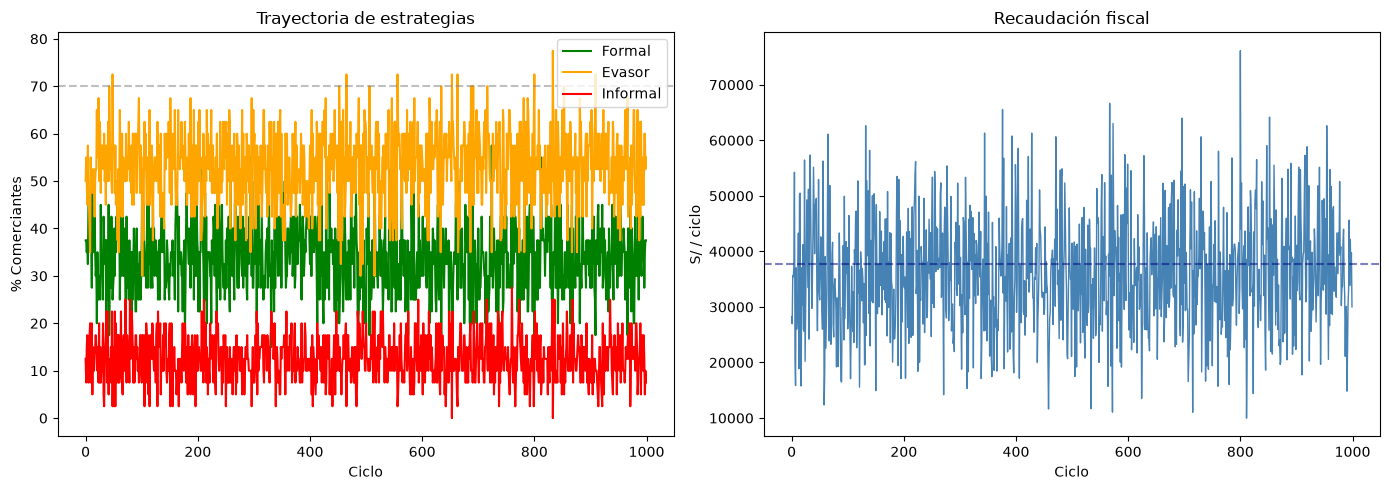


Equilibrio: 34% formal / 53% evasor / 12% informal


In [7]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Trayectoria de estrategias
ax = axes[0]
ax.plot(df.index, df["pct_formal"], color="green", label="Formal", linewidth=1.5)
ax.plot(df.index, df["pct_evasor"], color="orange", label="Evasor", linewidth=1.5)
ax.plot(df.index, df["pct_informal"], color="red", label="Informal", linewidth=1.5)
ax.set_xlabel("Ciclo")
ax.set_ylabel("% Comerciantes")
ax.set_title("Trayectoria de estrategias")
ax.legend()
ax.axhline(y=70, color="gray", linestyle="--", alpha=0.5, label="Target INEI 70%")

# Recaudación
ax = axes[1]
ax.plot(df.index, df["recaudacion"], color="steelblue", linewidth=1)
ax.set_xlabel("Ciclo")
ax.set_ylabel("S/ / ciclo")
ax.set_title("Recaudación fiscal")
ax.axhline(y=df["recaudacion"].tail(100).mean(), color="navy", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

print(f"\nEquilibrio: {tail['pct_formal'].mean():.0f}% formal / "
      f"{tail['pct_evasor'].mean():.0f}% evasor / "
      f"{tail['pct_informal'].mean():.0f}% informal")

 agresividad  formal  evasor  informal  informal_total
        0.05  27.975  35.850    36.175          72.025
        0.25  29.675  45.100    25.225          70.325
        0.55  34.500  53.375    12.125          65.500
        0.80  36.300  58.750     4.950          63.700
        0.95  37.075  61.875     1.050          62.925


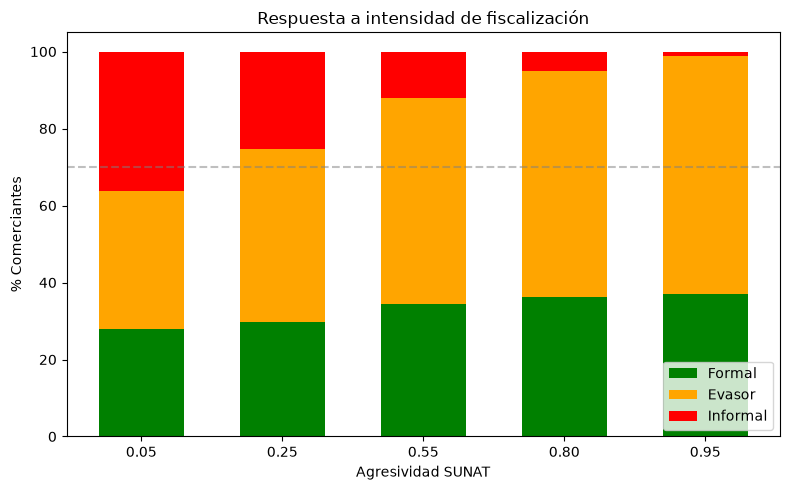

In [8]:
valores = [0.05, 0.25, 0.55, 0.80, 0.95]
resultados = []

for a in valores:
    m = ModeloGamarra(agresividad_sunat=a)
    for _ in range(1000):
        m.step()
    d = m.datacollector.get_model_vars_dataframe().tail(100)
    resultados.append({
        "agresividad": a,
        "formal": d["pct_formal"].mean(),
        "evasor": d["pct_evasor"].mean(),
        "informal": d["pct_informal"].mean(),
        "informal_total": d["pct_informal"].mean() + d["pct_evasor"].mean(),
        "recaudacion": d["recaudacion"].mean(),
    })

sweep_df = pd.DataFrame(resultados)
print(sweep_df[["agresividad", "formal", "evasor", "informal", "informal_total"]].to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 5))
x = range(len(valores))
ax.bar(x, sweep_df["formal"], color="green", label="Formal", width=0.6)
ax.bar(x, sweep_df["evasor"], bottom=sweep_df["formal"], color="orange", label="Evasor", width=0.6)
ax.bar(x, sweep_df["informal"], bottom=sweep_df["formal"]+sweep_df["evasor"], color="red", label="Informal", width=0.6)
ax.set_xticks(list(x))
ax.set_xticklabels([f"{v:.2f}" for v in valores])
ax.set_xlabel("Agresividad SUNAT")
ax.set_ylabel("% Comerciantes")
ax.set_title("Respuesta a intensidad de fiscalización")
ax.axhline(y=70, color="gray", linestyle="--", alpha=0.5)
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

     escenario  formal  evasor  informal  inf_total   recaudacion
    Línea base  34.500  53.375    12.125     65.500  37771.315109
  + Antigüedad  33.750  54.300    11.950     66.250  36461.541867
      + Sorteo  35.100  52.550    12.350     64.900  36272.748099
+ Multa progr.  33.475  54.300    12.225     66.525 145710.628705
         Combo  34.675  53.525    11.800     65.325 148026.968149


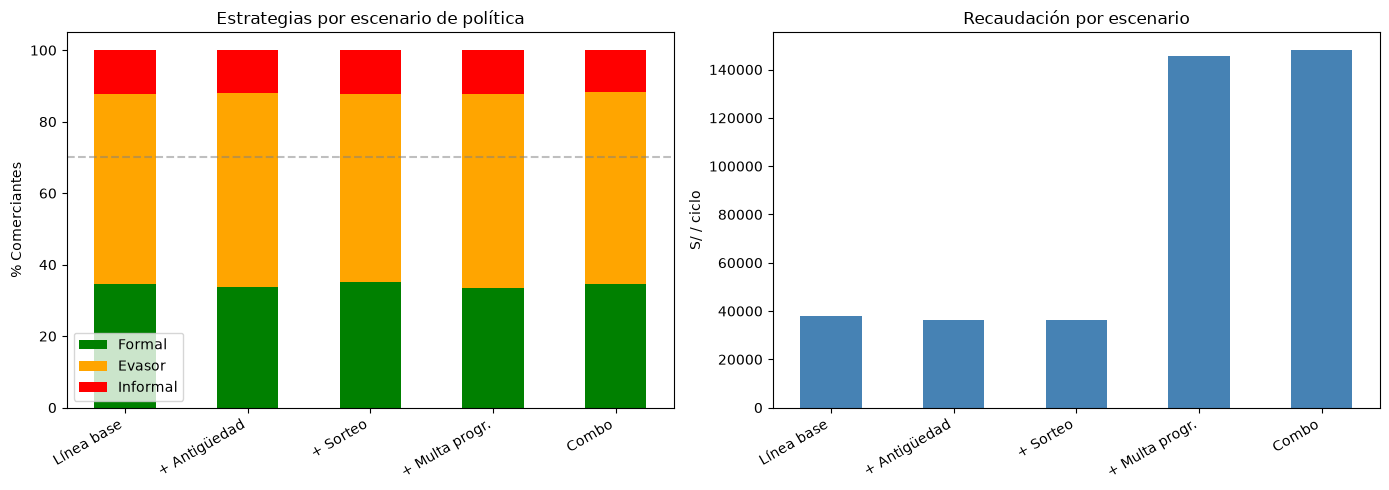

In [9]:
escenarios = {
    "Línea base": {},
    "+ Antigüedad": {"beneficio_antiguedad": True, "tasa_descuento_antiguedad": 0.08},
    "+ Sorteo": {"sorteo_comprobantes": True, "prob_sorteo": 0.03, "premio_sorteo": 100},
    "+ Multa progr.": {"multa_progresiva": True, "factor_reincidencia": 2.5},
    "Combo": {"beneficio_antiguedad": True, "sorteo_comprobantes": True,
              "multa_progresiva": True, "costo_fijo_formalidad": 200},
}

pol_results = []
for nombre, kwargs in escenarios.items():
    m = ModeloGamarra(**kwargs)
    for _ in range(1000):
        m.step()
    d = m.datacollector.get_model_vars_dataframe().tail(100)
    pol_results.append({
        "escenario": nombre,
        "formal": d["pct_formal"].mean(),
        "evasor": d["pct_evasor"].mean(),
        "informal": d["pct_informal"].mean(),
        "inf_total": d["pct_informal"].mean() + d["pct_evasor"].mean(),
        "recaudacion": d["recaudacion"].mean(),
    })

pol_df = pd.DataFrame(pol_results)
print(pol_df.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
x = range(len(escenarios))
ax.bar(x, pol_df["formal"], color="green", label="Formal", width=0.5)
ax.bar(x, pol_df["evasor"], bottom=pol_df["formal"], color="orange", label="Evasor", width=0.5)
ax.bar(x, pol_df["informal"], bottom=pol_df["formal"]+pol_df["evasor"], color="red", label="Informal", width=0.5)
ax.set_xticks(list(x))
ax.set_xticklabels(pol_df["escenario"], rotation=30, ha="right")
ax.set_ylabel("% Comerciantes")
ax.set_title("Estrategias por escenario de política")
ax.axhline(y=70, color="gray", linestyle="--", alpha=0.5)
ax.legend()

ax = axes[1]
ax.bar(x, pol_df["recaudacion"], color="steelblue", width=0.5)
ax.set_xticks(list(x))
ax.set_xticklabels(pol_df["escenario"], rotation=30, ha="right")
ax.set_ylabel("S/ / ciclo")
ax.set_title("Recaudación por escenario")

plt.tight_layout()
plt.show()

## Hallazgos

### El umbral de asfixia formal

Con costo laboral S/ 1,192 + contabilidad S/ 200, la carga fija supera S/ 1,392/mes —
**más del 35% de la facturación típica** (S/ 4,000). Con márgenes de 15-20%, el formal
opera con **pérdidas netas sistemáticas**. Formalizarse plenamente es ruta a la
inviabilidad financiera para la microempresa.

### El círculo vicioso de la moral tributaria

Muchos informales → base imponible contraída → menos recaudación → menos servicios →
moral cae → consumidores priorizan precio → informal vende más barato (sin IGV 18%) →
captura demanda → formal se asfixia. El bien informal es un **subsidio de mercado**
a la economía familiar pobre.

### Evasión sofisticada vs. destrucción de capital

Alta presión fiscal genera dos distorsiones:
1. **Evasión sofisticada:** comerciantes se registran (RUC aparente) pero siguen
   subdeclarando (alpha=60%). La fiscalización incrementa costos transaccionales
   sin elevar recaudación.
2. **Destrucción de capital:** informales de menor escala no absorben la multa
   (S/ 2,750), colapsan y se reincorporan como ambulantes móviles.

**Conclusión:** la coacción fiscal sola genera sistema inestable — evasión sofisticada
o quiebra masiva. Ninguna reduce estructuralmente la informalidad.

## Recomendaciones de Política Pública

El regulador **no puede maximizar simultáneamente** recaudación, estándares formales,
y estabilidad del empleo microempresarial. Cuatro recomendaciones:

1. **Sustituir multas por capacitación voluntaria.** Consolidar facultades preventivas
   de SUNAT: actas preventivas en primera infracción. Reduce destrucción de capital
   sin eliminar señalización de incumplimiento.

2. **Atenuar la brecha del costo laboral.** Cofinanciar aportes previsionales durante
   los primeros 3 años de REMYPE. Reducir `COSTO_FIJO_FORMALIDAD` hace la formalidad
   viable para más comerciantes.

3. **Simplificar y unificar regímenes tributarios.** Fusionar RER y RMT en un régimen
   progresivo único, eliminando topes rígidos que incentivan fragmentación artificial.

4. **Estimular la moral tributaria activa.** Sorteos de comprobantes + devolver % del
   IGV a consumidores que exijan boleta. Elevar `PESO_MORAL` reduce informalidad más
   que doblar `AGRESIVIDAD_SUNAT`.

**Ninguna palanca aislada basta.** Reducir al 50% requiere actuar en los tres frentes
simultáneamente: enforcement + reducción de costos + cultura tributaria.

## Dashboard Interactivo (Opcional)

Requiere: `pip install solara altair`

Ejecutar fuera del notebook: `PYTHONPATH=. solara run src/visualizacion.py`

El dashboard incluye grid visual con comerciantes coloreados, 19 sliders, 3 checkboxes
para políticas nuevas, 6 botones de preset, y gráficas en vivo.

In [10]:
# Celda opcional — requiere: pip install solara altair
# Ejecutar desde terminal: PYTHONPATH=. solara run src/visualizacion.py
#
# El dashboard (src/visualizacion.py) proporciona:
#
# - Grid visual: comerciantes cambian color (verde=formal, naranja=evasor, rojo=informal)
# - 19 sliders: agresividad, costo_fijo, IGV, multas, alpha, beta, pesos, etc.
# - 3 checkboxes: beneficio_antiguedad, sorteo_comprobantes, multa_progresiva
# - 6 presets: base, enforcement, subsidio, cultura, reduccion, combo
# - Gráficas en vivo: % estrategias + recaudación
#
# Para usarlo aquí en Jupyter, importar y mostrar:
#
# from mesa.visualization import JupyterViz
# from src.visualizacion import agent_portrayal, model_params
#
# page = JupyterViz(
#     ModeloGamarra,
#     model_params,
#     agent_portrayal,
#     components=[...],
#     name="El Trilema de Gamarra",
# )
# page
pass  # placeholder — ver src/visualizacion.py para el código completo